#

In [3]:

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

# load the data
df = pd.read_csv('../model/UNSW_NB15_testing-set.csv')
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ─────────────────────────────────────────────
# 1. Load datasets
# ─────────────────────────────────────────────
train_df = pd.read_csv("../model/UNSW_NB15_training-set.csv")
test_df  = pd.read_csv("../model/UNSW_NB15_testing-set.csv")

# ─────────────────────────────────────────────
# 2. Combine both splits into one
# ─────────────────────────────────────────────
df = pd.concat([train_df, test_df], ignore_index=True)
print(f"Combined shape: {df.shape}")

# ─────────────────────────────────────────────
# 3. Keep only DoS and Normal traffic
# ─────────────────────────────────────────────
df = df[df['attack_cat'].isin(['DoS', 'Normal'])]
print(f"After filtering DoS + Normal only: {df.shape}")
print(f"\nClass distribution:")
print(df['attack_cat'].value_counts())

# ─────────────────────────────────────────────
# 4. Create binary label
#    Normal = 0, DoS = 1
# ─────────────────────────────────────────────
df['label'] = df['attack_cat'].apply(lambda x: 1 if x == 'DoS' else 0)
print(f"\nBinary label distribution:")
print(df['label'].value_counts())
print(f"DoS ratio: {df['label'].mean()*100:.1f}%")

# ─────────────────────────────────────────────
# 5. Drop unnecessary columns
# ─────────────────────────────────────────────
drop_cols = ['id', 'label', 'attack_cat']
X = df.drop(columns=drop_cols, errors='ignore')
y = df['label']

# ─────────────────────────────────────────────
# 6. Encode categorical features
# ─────────────────────────────────────────────
cat_cols = ['proto', 'state', 'service']

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print(f"\nFeatures after encoding: {X.shape[1]}")

# ─────────────────────────────────────────────
# 7. Train/Test split — 70/30
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y       # preserves class ratio in both splits
)

print(f"\nX_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"  DoS ratio: {y_train.mean()*100:.1f}%")
print(f"\nTest class distribution:")
print(y_test.value_counts())
print(f"  DoS ratio: {y_test.mean()*100:.1f}%")

# ─────────────────────────────────────────────
# 8. Subset to final 6 features
# ─────────────────────────────────────────────
final_features = ['proto', 'sload', 'sbytes', 'smean', 'rate', 'dbytes']

X_train_final = X_train[final_features]
X_test_final  = X_test[final_features]

print(f"\nX_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape : {X_test_final.shape}")

Combined shape: (257673, 45)
After filtering DoS + Normal only: (109353, 45)

Class distribution:
attack_cat
Normal    93000
DoS       16353
Name: count, dtype: int64

Binary label distribution:
label
0    93000
1    16353
Name: count, dtype: int64
DoS ratio: 15.0%

Features after encoding: 42

X_train shape : (76547, 42)
X_test shape  : (32806, 42)

Train class distribution:
label
0    65100
1    11447
Name: count, dtype: int64
  DoS ratio: 15.0%

Test class distribution:
label
0    27900
1     4906
Name: count, dtype: int64
  DoS ratio: 15.0%

X_train_final shape: (76547, 6)
X_test_final shape : (32806, 6)


In [5]:
# Full dataset
full_size = len(pd.concat([train_df, test_df], ignore_index=True))

# After filtering DoS + Normal only
dos_normal_size = len(df)

# Breakdown
normal_count = len(df[df['attack_cat'] == 'Normal'])
dos_count    = len(df[df['attack_cat'] == 'DoS'])
dropped      = full_size - dos_normal_size

print(f"Full combined dataset : {full_size:,}")
print(f"After DoS + Normal   : {dos_normal_size:,}")
print(f"Samples dropped      : {dropped:,} ({dropped/full_size*100:.1f}%)")
print(f"\nBreakdown:")
print(f"  Normal : {normal_count:,} ({normal_count/dos_normal_size*100:.1f}%)")
print(f"  DoS    : {dos_count:,}    ({dos_count/dos_normal_size*100:.1f}%)")
print(f"\nTrain (70%) : {int(dos_normal_size * 0.70):,}")
print(f"Test  (30%) : {int(dos_normal_size * 0.30):,}")

Full combined dataset : 257,673
After DoS + Normal   : 109,353
Samples dropped      : 148,320 (57.6%)

Breakdown:
  Normal : 93,000 (85.0%)
  DoS    : 16,353    (15.0%)

Train (70%) : 76,547
Test  (30%) : 32,805


Training Random Forest for feature importance...
Done.
Computing permutation importance...
Done.


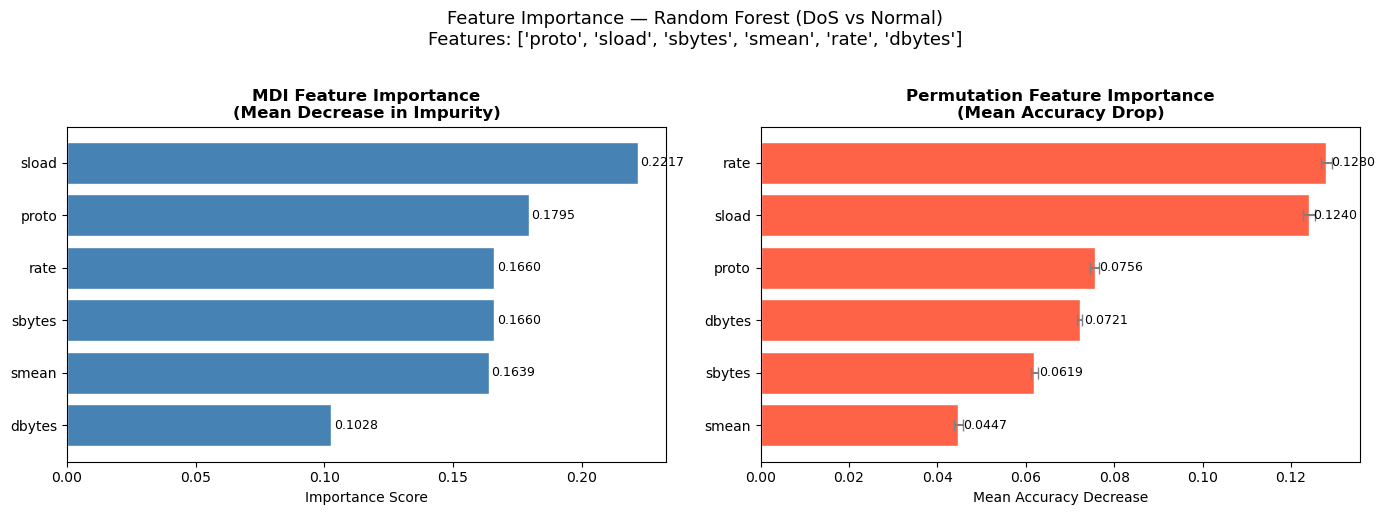


Feature Importance Ranking:
        MDI Importance  MDI Rank  Permutation Importance  Permutation Std  Perm Rank
sload          0.22175         1                 0.12401          0.00130          2
proto          0.17953         2                 0.07559          0.00099          3
rate           0.16604         3                 0.12800          0.00117          1
sbytes         0.16595         4                 0.06195          0.00075          5
smean          0.16394         5                 0.04474          0.00101          6
dbytes         0.10279         6                 0.07213          0.00066          4


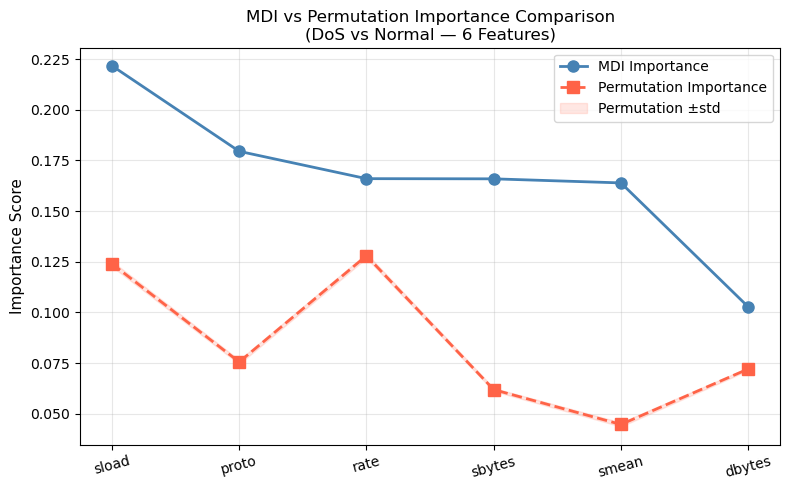

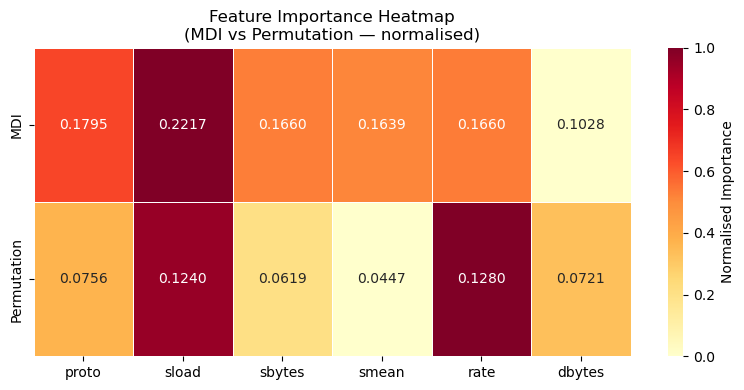

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# ─────────────────────────────────────────────
# 1. Train RF on final 6 features
# ─────────────────────────────────────────────
print("Training Random Forest for feature importance...")
rf_imp = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_imp.fit(X_train_final, y_train)
print("Done.")

# ─────────────────────────────────────────────
# 2. MDI — Mean Decrease in Impurity
# ─────────────────────────────────────────────
mdi_importances = pd.Series(
    rf_imp.feature_importances_,
    index=final_features
).sort_values(ascending=True)

# ─────────────────────────────────────────────
# 3. Permutation Importance
# ─────────────────────────────────────────────
print("Computing permutation importance...")
perm_result = permutation_importance(
    rf_imp, X_test_final, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importances = pd.Series(
    perm_result.importances_mean,
    index=final_features
).sort_values(ascending=True)

perm_std = perm_result.importances_std[
    np.argsort(perm_result.importances_mean)
]
print("Done.")

# ─────────────────────────────────────────────
# 4. Plot MDI and Permutation side by side
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MDI
axes[0].barh(mdi_importances.index,
             mdi_importances.values,
             color='steelblue', edgecolor='white')
axes[0].set_title('MDI Feature Importance\n(Mean Decrease in Impurity)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, v in enumerate(mdi_importances.values):
    axes[0].text(v + 0.001, i, f'{v:.4f}',
                 va='center', fontsize=9)

# Permutation
axes[1].barh(perm_importances.index,
             perm_importances.values,
             xerr=perm_std,
             color='tomato', edgecolor='white',
             error_kw={'ecolor': 'gray', 'capsize': 4})
axes[1].set_title('Permutation Feature Importance\n(Mean Accuracy Drop)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mean Accuracy Decrease')
for i, v in enumerate(perm_importances.values):
    axes[1].text(v + 0.001, i, f'{v:.4f}',
                 va='center', fontsize=9)

plt.suptitle('Feature Importance — Random Forest (DoS vs Normal)\n'
             f'Features: {final_features}',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('feature_importance_mdi_perm.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 5. Combined ranking table
# ─────────────────────────────────────────────
importance_df = pd.DataFrame({
    'MDI Importance'        : rf_imp.feature_importances_,
    'MDI Rank'              : pd.Series(rf_imp.feature_importances_)
                               .rank(ascending=False).astype(int).values,
    'Permutation Importance': perm_result.importances_mean,
    'Permutation Std'       : perm_result.importances_std,
    'Perm Rank'             : pd.Series(perm_result.importances_mean)
                               .rank(ascending=False).astype(int).values,
}, index=final_features).sort_values('MDI Importance', ascending=False)

print("\nFeature Importance Ranking:")
print(importance_df.round(5).to_string())

# ─────────────────────────────────────────────
# 6. Dot plot — MDI vs Permutation comparison
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

x    = np.arange(len(final_features))
mdi  = importance_df['MDI Importance'].values
perm = importance_df['Permutation Importance'].values
feat = importance_df.index.tolist()

ax.plot(x, mdi,  'o-', color='steelblue', lw=2,
        markersize=8, label='MDI Importance')
ax.plot(x, perm, 's--', color='tomato', lw=2,
        markersize=8, label='Permutation Importance')
ax.fill_between(x,
                perm - importance_df['Permutation Std'].values,
                perm + importance_df['Permutation Std'].values,
                alpha=0.15, color='tomato', label='Permutation ±std')

ax.set_xticks(x)
ax.set_xticklabels(feat, rotation=15, fontsize=10)
ax.set_ylabel('Importance Score', fontsize=11)
ax.set_title('MDI vs Permutation Importance Comparison\n'
             '(DoS vs Normal — 6 Features)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('mdi_vs_perm_importance.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────
# 7. Heatmap of importance scores
# ─────────────────────────────────────────────
heat_df = pd.DataFrame({
    'MDI'        : rf_imp.feature_importances_,
    'Permutation': perm_result.importances_mean,
}, index=final_features)

# Normalise to 0-1 for fair visual comparison
heat_df_norm = (heat_df - heat_df.min()) / (heat_df.max() - heat_df.min())

plt.figure(figsize=(8, 4))
import seaborn as sns
sns.heatmap(heat_df_norm.T,
            annot=heat_df.T.round(4),
            fmt='.4f',
            cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'Normalised Importance'})
plt.title('Feature Importance Heatmap\n'
          '(MDI vs Permutation — normalised)', fontsize=12)
plt.tight_layout()
plt.savefig('importance_heatmap.png', dpi=150)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, ConfusionMatrixDisplay,
                              roc_curve, precision_recall_curve)
from imblearn.combine import SMOTEENN
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────
# 2. Train Random Forest
# ─────────────────────────────────────────────
print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf  = rf.predict(X_test_final)
y_prob_rf  = rf.predict_proba(X_test_final)[:, 1]
print("Done.")


print("Training Isolation Forest...")
contamination = float(pd.Series(y_train_resampled).mean())
isof = IsolationForest(
    n_estimators=100,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
isof.fit(X_train_resampled)
y_pred_isof  = np.where(isof.predict(X_test_final) == -1, 1, 0)
y_score_isof = -isof.decision_function(X_test_final)
print("Done.")


print("\n" + "="*55)
print("  RANDOM FOREST — Classification Report")
print("="*55)
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Normal', 'DoS']
))

print("="*55)
print("  ISOLATION FOREST — Classification Report")
print("="*55)
print(classification_report(
    y_test, y_pred_isof,
    target_names=['Normal', 'DoS']
))


summary = pd.DataFrame({
    'Random Forest' : [
        accuracy_score(y_test,  y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test,    y_pred_rf),
        f1_score(y_test,        y_pred_rf),
        roc_auc_score(y_test,   y_prob_rf),
    ],
    'Isolation Forest' : [
        accuracy_score(y_test,  y_pred_isof),
        precision_score(y_test, y_pred_isof),
        recall_score(y_test,    y_pred_isof),
        f1_score(y_test,        y_pred_isof),
        roc_auc_score(y_test,   y_score_isof),
    ],
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
).round(4)

print("\n── Metrics Summary ──────────────────────────────────")
print(summary.to_string())

# ─────────────────────────────────────────────
# 6. Confusion Matrices
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred) in zip(axes, [
    ('Random Forest',    y_pred_rf),
    ('Isolation Forest', y_pred_isof)
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Normal', 'DoS'],
        cmap='Blues', ax=ax, colorbar=False
    )
    # Annotate TP TN FP FN
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    ax.set_title(f'{name}\n'
                 f'TP={tp:,}  TN={tn:,}  FP={fp:,}  FN={fn:,}',
                 fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — DoS vs Normal Traffic\n'
             f'(6 features, SMOTEENN balanced)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_dos.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 7. Metrics Bar Chart
# ─────────────────────────────────────────────
metrics    = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
rf_scores  = summary['Random Forest'].values
if_scores  = summary['Isolation Forest'].values

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, rf_scores, width,
               label='Random Forest',
               color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, if_scores, width,
               label='Isolation Forest',
               color='tomato', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Classification Metrics — Random Forest vs Isolation Forest\n'
             'Top 6 features',
             fontsize=12)
ax.axhline(y=0.90, color='gray', linestyle='--',
           alpha=0.4, label='0.90 reference')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('metrics_bar_dos.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────
# 8. ROC Curves
# ─────────────────────────────────────────────
fpr_rf,   tpr_rf,   _ = roc_curve(y_test, y_prob_rf)
fpr_isof, tpr_isof, _ = roc_curve(y_test, y_score_isof)

roc_rf   = roc_auc_score(y_test, y_prob_rf)
roc_isof = roc_auc_score(y_test, y_score_isof)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf,   tpr_rf,
         color='steelblue', lw=2,
         label=f'Random Forest    (AUC = {roc_rf:.4f})')
plt.plot(fpr_isof, tpr_isof,
         color='tomato', lw=2,
         label=f'Isolation Forest (AUC = {roc_isof:.4f})')
plt.plot([0, 1], [0, 1],
         'k--', alpha=0.4, label='Random baseline')
plt.fill_between(fpr_rf, tpr_rf, alpha=0.08, color='steelblue')
plt.fill_between(fpr_isof, tpr_isof, alpha=0.08, color='tomato')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate',  fontsize=11)
plt.title('ROC Curves — DoS vs Normal\n'
          'Top 6 features',
          fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_dos.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────
# 9. Precision-Recall Curves
# ─────────────────────────────────────────────
prec_rf,   rec_rf,   _ = precision_recall_curve(y_test, y_prob_rf)
prec_isof, rec_isof, _ = precision_recall_curve(y_test, y_score_isof)

baseline = y_test.mean()

plt.figure(figsize=(8, 6))
plt.plot(rec_rf,   prec_rf,
         color='steelblue', lw=2,
         label=f'Random Forest    (F1={f1_score(y_test, y_pred_rf):.4f})')
plt.plot(rec_isof, prec_isof,
         color='tomato', lw=2,
         label=f'Isolation Forest (F1={f1_score(y_test, y_pred_isof):.4f})')
plt.axhline(y=baseline, color='gray',
            linestyle='--', alpha=0.5,
            label=f'Baseline (DoS ratio={baseline:.2f})')
plt.xlabel('Recall',    fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Precision-Recall Curves — DoS vs Normal\n'
          'Top 6 features',
          fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves_dos.png', dpi=150)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score)
from imblearn.combine import SMOTEENN
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────
# 1. Define feature counts to benchmark
# ─────────────────────────────────────────────
feature_counts = [6, 8, 10, 12, 15]  # includes your current 6 as baseline

# ─────────────────────────────────────────────
# 2. Use RF importance to rank ALL features
#    so we can select top N for each benchmark
# ─────────────────────────────────────────────
print("Ranking all features by RF importance...")
rf_ranker = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
rf_ranker.fit(X_train, y_train)

feature_ranking = pd.Series(
    rf_ranker.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 15 features by RF importance:")
print(feature_ranking.head(15).round(5).to_string())

# ─────────────────────────────────────────────
# 3. Benchmark loop
# ─────────────────────────────────────────────
results_rf   = []
results_isof = []

for n in feature_counts:
    print(f"\n{'='*50}")
    print(f"  Benchmarking top {n} features")
    print(f"{'='*50}")

    # Select top N features by RF importance
    top_n_features = feature_ranking.head(n).index.tolist()
    print(f"  Features: {top_n_features}")

    X_train_n = X_train[top_n_features]
    X_test_n  = X_test[top_n_features]

    # Apply SMOTEENN
    smoteenn = SMOTEENN(random_state=42)
    X_train_res, y_train_res = smoteenn.fit_resample(X_train_n, y_train)

    # ── Random Forest ─────────────────────────
    rf_n = RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    )
    rf_n.fit(X_train_res, y_train_res)
    y_pred_rf_n = rf_n.predict(X_test_n)
    y_prob_rf_n = rf_n.predict_proba(X_test_n)[:, 1]

    results_rf.append({
        'N Features' : n,
        'Features'   : top_n_features,
        'Accuracy'   : accuracy_score(y_test,  y_pred_rf_n),
        'Precision'  : precision_score(y_test, y_pred_rf_n, zero_division=0),
        'Recall'     : recall_score(y_test,    y_pred_rf_n, zero_division=0),
        'F1-Score'   : f1_score(y_test,        y_pred_rf_n, zero_division=0),
        'ROC-AUC'    : roc_auc_score(y_test,   y_prob_rf_n),
    })

    print(f"  RF  — Accuracy: {results_rf[-1]['Accuracy']:.4f} "
          f"F1: {results_rf[-1]['F1-Score']:.4f} "
          f"Recall: {results_rf[-1]['Recall']:.4f}")

    # ── Isolation Forest ──────────────────────
    contamination = min(float(y_train_res.mean()), 0.499)
    isof_n = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )
    isof_n.fit(X_train_res)
    y_pred_isof_n  = np.where(
        isof_n.predict(X_test_n) == -1, 1, 0
    )
    y_score_isof_n = -isof_n.decision_function(X_test_n)

    results_isof.append({
        'N Features' : n,
        'Accuracy'   : accuracy_score(y_test,  y_pred_isof_n),
        'Precision'  : precision_score(y_test, y_pred_isof_n, zero_division=0),
        'Recall'     : recall_score(y_test,    y_pred_isof_n, zero_division=0),
        'F1-Score'   : f1_score(y_test,        y_pred_isof_n, zero_division=0),
        'ROC-AUC'    : roc_auc_score(y_test,   y_score_isof_n),
    })

    print(f"  IF  — Accuracy: {results_isof[-1]['Accuracy']:.4f} "
          f"F1: {results_isof[-1]['F1-Score']:.4f} "
          f"Recall: {results_isof[-1]['Recall']:.4f}")

df_rf   = pd.DataFrame(results_rf).set_index('N Features').drop('Features', axis=1)
df_isof = pd.DataFrame(results_isof).set_index('N Features')

print("\n── Random Forest Benchmark ──────────────────────────")
print(df_rf.round(4).to_string())

print("\n── Isolation Forest Benchmark ───────────────────────")
print(df_isof.round(4).to_string())


metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (df_res, name, color) in zip(axes, [
    (df_rf,   'Random Forest',    'steelblue'),
    (df_isof, 'Isolation Forest', 'tomato')
]):
    for metric, style in zip(
        metrics_to_plot,
        ['-o', '-s', '-^', '-D', '-v']
    ):
        ax.plot(df_res.index, df_res[metric],
                style, lw=2, markersize=7,
                label=metric)

    ax.set_xticks(feature_counts)
    ax.set_xlabel('Number of Features', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{name}\nMetrics vs Feature Count',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.axvline(x=6, color='gray', linestyle='--',
               alpha=0.5, label='Current (6 features)')

plt.suptitle('Feature Count Benchmark — RF vs Isolation Forest\n'
             '(DoS vs Normal, SMOTEENN balanced)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('feature_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 6. F1 comparison heatmap
# ─────────────────────────────────────────────
import seaborn as sns

heatmap_data = pd.DataFrame({
    'Random Forest'   : df_rf['F1-Score'],
    'Isolation Forest': df_isof['F1-Score'],
})

plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_data.T,
            annot=True, fmt='.4f',
            cmap='YlGn',
            linewidths=0.5,
            cbar_kws={'label': 'F1-Score'})
plt.title('F1-Score Heatmap — Feature Count Benchmark', fontsize=12)
plt.xlabel('Number of Features')
plt.tight_layout()
plt.savefig('benchmark_heatmap.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────
# 7. Identify optimal feature count
# ─────────────────────────────────────────────
best_rf_n   = df_rf['F1-Score'].idxmax()
best_isof_n = df_isof['F1-Score'].idxmax()

print(f"\n── Optimal Feature Count ────────────────────────────")
print(f"Random Forest    best F1 at {best_rf_n}   features: "
      f"{df_rf.loc[best_rf_n, 'F1-Score']:.4f}")
print(f"Isolation Forest best F1 at {best_isof_n} features: "
      f"{df_isof.loc[best_isof_n, 'F1-Score']:.4f}")
print(f"\nYour current 6-feature set:")
print(f"  RF   F1: {df_rf.loc[6, 'F1-Score']:.4f}")
print(f"  IF   F1: {df_isof.loc[6, 'F1-Score']:.4f}")

Ranking all features by RF importance...


NameError: name 'X_train' is not defined

In [15]:
# Check which model variables exist in your session
import sys

model_names = ['rf', 'rf_smote', 'rf_smoteenn', 
               'model', 'rf_n', 'rf_imp', 'clf']

for name in model_names:
    if name in dir():
        print(f"Found: {name}")

Found: rf
Found: rf_imp


In [ ]:

import json
import numpy as np

def export_rf_to_json(model, feature_names, output_path):
    """
    Export trained Random Forest to JSON
    for P4 table population.
    """
    trees = []

    for i, estimator in enumerate(model.estimators_):
        tree  = estimator.tree_
        nodes = []

        for node_id in range(tree.node_count):
            if tree.children_left[node_id] == -1:
                # Leaf node — return majority class
                node = {
                    'id'      : int(node_id),
                    'is_leaf' : True,
                    'class'   : int(np.argmax(
                                    tree.value[node_id]))
                }
            else:
                # Decision node
                feat_idx = int(tree.feature[node_id])
                node = {
                    'id'           : int(node_id),
                    'is_leaf'      : False,
                    'feature'      : feature_names[feat_idx],
                    'feature_idx'  : feat_idx,
                    # Raw float threshold
                    'threshold'    : float(
                                        tree.threshold[node_id]),
                    # Quantised integer (multiply by 1000)
                    'threshold_int': int(
                                        tree.threshold[node_id]
                                        * 1000),
                    'left_child'   : int(
                                        tree.children_left[node_id]),
                    'right_child'  : int(
                                        tree.children_right[node_id])
                }
            nodes.append(node)

        trees.append({
            'tree_id'  : i,
            'n_nodes'  : tree.node_count,
            'nodes'    : nodes
        })

    export = {
        'model_type'   : 'RandomForestClassifier',
        'n_trees'      : len(model.estimators_),
        'n_features'   : len(feature_names),
        'feature_names': list(feature_names),
        'classes'      : [0, 1],
        'trees'        : trees
    }

    with open(output_path, 'w') as f:
        json.dump(export, f, indent=2)

    # Print summary
    total_nodes = sum(t['n_nodes'] for t in trees)
    print(f"Exported successfully:")
    print(f"  Trees   : {len(trees)}")
    print(f"  Features: {feature_names}")
    print(f"  Nodes   : {total_nodes} total")
    print(f"  Saved to: {output_path}")

    return export

final_features = [
    'sttl', 'ct_state_ttl', 'rate',
    'dload', 'sinpkt', 'smean'
]

rf_export = export_rf_to_json(
    rf,                         # your trained RF model
    final_features,
    'rf_model.json'
)

Exported successfully:
  Trees   : 100
  Features: ['sttl', 'ct_state_ttl', 'rate', 'dload', 'sinpkt', 'smean']
  Nodes   : 223164 total
  Saved to: rf_model.json
